In [23]:
import math
import pandas as pd
import numpy as np
import json

# READ & CLEAN DATA

- drop testing workerids
- remove duplicates (item getting recorded multiple times by Multitude for some reason)

In [50]:
df = pd.read_csv("./dataRaw/experiment_6323_results.csv")

unnecessary_cols = ["questionid", "filename", "listnumber", "assignmentid", "hitid", "origin", "timestamp", "partid", "imgorder"]
unformatted_df = df.drop(unnecessary_cols, axis=1)

testworkers = ["test", "123", "testFirefox", "testRedirect", "testFinal"]  # add more to this list if there were more test runs
unformatted_df = unformatted_df[~unformatted_df["workerid"].isin(testworkers)]

len(unformatted_df["workerid"].unique())

101

## FORMAT RATING VALUES FROM THE ANSWER COLUMN

In [51]:
def format_answer(answer, weak_word, strong_word, antonym):
    """
    returns multiple results.
    whatever data is needed out of the answer, edit and manipulate it in this function
    """
    results = json.loads(json.loads(answer))
    new_dict = dict()
    
    if not results.get("ratings"):
        return None, None, None, None, None
    for item in results["ratings"]:
        name = item["image"].replace(".png", "")
        new_dict.update(
            {name: item["rating"]}
        )

    if results["speaker"] in ["frank", "bri"]:
        speakerType = "native"
    else:
        speakerType = "nonnative"
    
    if results["speaker"] in ["bri", "sasha"]:
        speakerGender = "female"
    else:
        speakerGender = "male"

    # weak word rating, strong word rating, antonym rating
    return new_dict.get(weak_word), new_dict.get(strong_word), new_dict.get(antonym), speakerType, speakerGender

In [52]:
answers_only_df = unformatted_df.apply(
    lambda x: format_answer(x.answer, x.weak, x.strong, x.antonym), 
    axis=1, 
    result_type="expand",  # this is how you make it into multiple columns
)
answers_only_df.columns=["derivationStrength", "strongRating", "antonymRating", "speakerType", "speakerGender"]
answers_only_df

,derivationStrength,strongRating,antonymRating,speakerType,speakerGender
1,90.0,10.0,0.0,nonnative,male
2,100.0,0.0,0.0,nonnative,female
3,35.0,60.0,5.0,native,female
4,94.0,6.0,0.0,nonnative,male
5,100.0,0.0,0.0,nonnative,male
...,...,...,...,...,...
3448,100.0,0.0,0.0,nonnative,female
3449,100.0,0.0,0.0,native,female
3450,100.0,0.0,0.0,nonnative,female
3451,100.0,0.0,0.0,native,male


## READ WORD FREQ DICT IN

In [53]:
word_freq_dict_df = pd.read_csv("./dataRaw/wordFreqDict.csv")
word_freq_dict_df.head()

word_freq_dict_df[word_freq_dict_df['Frequency'].isin(["x"])]

,Word,Rank,Frequency


## DATAFRAME CLEAN UP

1. concat the formatted answers dataframe back into the original and drop the old answers column that contained ALL the audio information
2. rename column names to be what is required in the models
3. trialid - each participant, set to 1 - 32 instead of the unique IDs each trial got
4. drop rows with NAs

In [120]:
answers_df = pd.concat([unformatted_df, answers_only_df], axis=1)
answers_df = answers_df.drop(["answer"], axis=1)

answers_df = answers_df.rename(columns={
    "workerid": "participantId",
    "itemid": "itemId",
    "type": "itemType",
    "id": "trialid"
})

# create a minimum column based on the participantId group by, then subtract that from all the trial ids 
# add 1 so we have range 1 - 32 on the trial ids. 
answers_df["trialidmin"] = answers_df.groupby("participantId")["trialid"].transform("min")
answers_df["newtrialid"] = (answers_df["trialid"] - answers_df["trialidmin"] + 1)
answers_df = answers_df.drop(["trialid", "trialidmin"], axis=1)
answers_df = answers_df.rename(columns={
    "newtrialid": "trialid"
})

# there are three participants whose submission went through twice at the time or within 2 seconds of each other
# 1) for one participant - one submission was all NaNs and the other had proper values in it
#    so we just drop the NaN values and take the submission with values in it
# 2) for two participants - same answer values for two submissions, we'll take the first set of submissions
answers_df = answers_df.dropna(subset=["derivationStrength"])
drop_rows = answers_df[answers_df["trialid"] > 32].index
answers_df.drop(drop_rows, inplace=True)

answers_df.shape

(3232, 14)

# FILTER - EXCLUSION CRITERIA

### Picture Rating Control Trials

In [121]:
# filter out rating scores
#    - if avg. rating across all unambiguous trials were < 80%
umambiguous_trials = answers_df[answers_df["itemType"] == "unambiguous"]
picrating_filtered_participants = list(
    pd.unique(
        umambiguous_trials.groupby("participantId").filter(
            lambda x: x["derivationStrength"].mean() < 80
        )["participantId"]
    )
)
picrating_filtered_participants

[]

### Picture Rating Technical Problems

In [122]:
# make sure there are not any NaN values in derivationStrength
countNaN = answers_df["derivationStrength"].isnull().groupby(
    answers_df["participantId"]
).sum().astype(int).reset_index(name="countNaN")
NaNTrials = list(countNaN[countNaN["countNaN"] > 1]["participantId"].unique())

# make sure there are no participants who have weird number of submissions
not32trials = list(answers_df.groupby("participantId").filter(
    lambda x: x["trialid"].count() != 32
)["participantId"].unique())

technical_prob_filtered_participants = NaNTrials + not32trials
technical_prob_filtered_participants

[]

## ToM Filtered Participants

These participants are identified after running the `nathan.R` script:
- technical problems (anything over 10% of responses missing): grab from `/dataOutput/ToM/failed_questions.csv` file
- control accuracy < 80: is in the output of the R script

In [123]:
nathan4u_filtered_participants = [
    # technical issues: 50+ unanswered
    "69c093d33989aa791c4e8b2d", 
    "6a2482e9af72b55296872b0d",
    "6a1f0ef7a64d44c972d3a5f7",
    "6a00dbcc626a780a8e5c07a4",
    "6a177f7ec67996448d9c7d41",
    "6a232745f21e165e2b54ed58",

    # control accuracy < 50%
    "6978d830c5d415696508430d",
    "69c093d33989aa791c4e8b2d",
    "6a00dbcc626a780a8e5c07a4", 
    "6a177f7ec67996448d9c7d41",
    "6a1f0ef7a64d44c972d3a5f7",
    "6a232745f21e165e2b54ed58",
    "6a2482e9af72b55296872b0d"
]

## Audio Filtered Participants

After transcribing the audio for the two practice perspective taking trials, any that did not choose the target word will be excluded.

Anyone who did not provide a response that is indicative of understanding the task in the final critical audio explanation will be excluded.

In [124]:
audio_filtered_participants = [
    # Missed any of the perspective taking trials (from the already filtered participants)
    "69f7b962446b32b08d58a1df",
    "69e816058da70eddb5dbc3e1",
    "69f6484996726366cacd162c",
    "69efe0b03221edd72686c185",
    "69ed15278090fe4438301d5c",
    "6a0a0fd9f370053c3505dc0f",
    "66da162f5538535e93490441",
    "69d5632f4815bcc4cb7242bf",
    "69cec122e3cb56c2e7000c6b",
    "6a012d3c523e7311f4e55f61",
    "69a0734d1d433d3694c8438f",
    "69e957ad6c65e153a1c65ae2",

    # from the final run
    "6980dfb784202dcf9736910f",
    "69d5c4d748bcaf8026c80573",
    "6a15dfdb880253e5b6b917f3",
    "697a495862ac67423e8418b8",
]

## Total Filtered Participants

In [125]:
all_filtered_participants = list(set(
    picrating_filtered_participants + 
    # ratingoutlier_participants +
    nathan4u_filtered_participants + 
    audio_filtered_participants + 
    technical_prob_filtered_participants
))

print("total number of filtered participants: ", len(all_filtered_participants))
all_filtered_participants

total number of filtered participants:  23


['69a0734d1d433d3694c8438f',
 '6980dfb784202dcf9736910f',
 '697a495862ac67423e8418b8',
 '69efe0b03221edd72686c185',
 '69e957ad6c65e153a1c65ae2',
 '6a232745f21e165e2b54ed58',
 '69ed15278090fe4438301d5c',
 '69f7b962446b32b08d58a1df',
 '69c093d33989aa791c4e8b2d',
 '69d5c4d748bcaf8026c80573',
 '69d5632f4815bcc4cb7242bf',
 '6a15dfdb880253e5b6b917f3',
 '6a0a0fd9f370053c3505dc0f',
 '66da162f5538535e93490441',
 '69cec122e3cb56c2e7000c6b',
 '69e816058da70eddb5dbc3e1',
 '69f6484996726366cacd162c',
 '6a177f7ec67996448d9c7d41',
 '6a00dbcc626a780a8e5c07a4',
 '6a1f0ef7a64d44c972d3a5f7',
 '6a2482e9af72b55296872b0d',
 '6978d830c5d415696508430d',
 '6a012d3c523e7311f4e55f61']

In [126]:
answers_df = answers_df[~answers_df["participantId"].isin(all_filtered_participants)]

In [127]:
answers_df["participantId"].unique()

<StringArray>
['62c5f85ccf34c8d9c0650f6e', '65465c5bc5a014ec683d55cf',
 '661c09a749790db73f8faba5', '66315563a848526fcfa7555b',
 '66577b950cf252021eff76f8', '665795d82a087799023aaf0e',
 '676956116c1a3416bf7b2afe', '695ea002344d7ca1605c747a',
 '6965bd850ce22095dd7a84ca', '69864a705614c15728117b35',
 '6987875a0a8fa6ed9ef00726', '699b610e2ba4bade6f39121b',
 '699cebf39bc275a312ffd51c', '699d45af20adaa6e1e89aa5a',
 '699e3cc79b0d3d96b469ca49', '69a6eb2bc679065ed1cecc51',
 '69a8cff018bead25e4a5d848', '69b19e44edf4d70aee145c16',
 '69b3193cce0978ad6db9fe7c', '69b5c6bdbcf55371066f5e73',
 '69ba37faee13f176e7635323', '69bdf2afe629d42bfc47997f',
 '69c1256faa88d6296c98d745', '69c2f0033339865c279814ca',
 '69c6ec3a92185003cf70ded5', '69cc1fac2b52b1c4dd21cc7d',
 '69d2a8765e19038ab2fc0f56', '69daf476f6bc0d990581aca6',
 '69dbf4749918745fc7d8e820', '69dc76f0a77a620367d666ec',
 '69dfe696c433039b7add8013', '69e599577d00fb31c54fb004',
 '69f0438cc141b27ed949788e', '69f3d4f3fb7630947c56f1eb',
 '69f674db81cb466

# MERGE DFs TOGETHER

## all the word information back into the response dataframe

In [128]:
# get the weak word info
final_df = answers_df.merge(word_freq_dict_df, left_on="weak", right_on="Word")
final_df = final_df.drop(["Word"], axis=1)
final_df = final_df.rename(columns={
    "Rank": "weakRank",
    "Frequency": "weakFreq",
})

# get the strong word info
final_df = final_df.merge(word_freq_dict_df, left_on="strong", right_on="Word")
final_df = final_df.drop(["Word"], axis=1)
final_df = final_df.rename(columns={
    "Rank": "strongRank",
    "Frequency": "strongFreq",
})

# get the antonym word info
final_df = final_df.merge(word_freq_dict_df, left_on="antonym", right_on="Word")
final_df = final_df.drop(["Word"], axis=1)
final_df = final_df.rename(columns={
    "Rank": "antonymRank",
    "Frequency": "antonymFreq",
})

# create freq ratios
cols = ["weakFreq", "strongFreq", "antonymFreq", "weakRank", "strongRank", "antonymRank"]
final_df[cols] = final_df[cols].apply(pd.to_numeric, errors='coerce', axis=1)
final_df["freqRatio"] = final_df["weakFreq"] / final_df["strongFreq"]
# if freq ratio is nan, fill it with 2
final_df["freqRatio"] = final_df["freqRatio"].apply(lambda x: math.log10(x))
final_df.head(6)

,participantId,itemId,itemType,weak,strong,antonym,lowfreq1,lowfreq2,derivationStrength,strongRating,...,speakerType,speakerGender,trialid,weakRank,weakFreq,strongRank,strongFreq,antonymRank,antonymFreq,freqRatio
0,62c5f85ccf34c8d9c0650f6e,1,critical,soft,mushy,crunchy,panicked,introspective,90.0,10.0,...,nonnative,male,21,1381,27970,18362,478,14284,834,1.767265
1,65465c5bc5a014ec683d55cf,1,critical,soft,mushy,crunchy,panicked,introspective,100.0,0.0,...,nonnative,female,17,1381,27970,18362,478,14284,834,1.767265
2,661c09a749790db73f8faba5,1,critical,soft,mushy,crunchy,panicked,introspective,35.0,60.0,...,native,female,17,1381,27970,18362,478,14284,834,1.767265
3,66315563a848526fcfa7555b,1,critical,soft,mushy,crunchy,panicked,introspective,94.0,6.0,...,nonnative,male,9,1381,27970,18362,478,14284,834,1.767265
4,66577b950cf252021eff76f8,1,critical,soft,mushy,crunchy,panicked,introspective,100.0,0.0,...,nonnative,male,19,1381,27970,18362,478,14284,834,1.767265
5,665795d82a087799023aaf0e,1,critical,soft,mushy,crunchy,panicked,introspective,0.0,100.0,...,nonnative,female,13,1381,27970,18362,478,14284,834,1.767265


In [129]:
final_df.shape

(2496, 21)

## read and merge the ToM scores in

In [130]:
tom_scores_df = pd.read_csv("./dataOutput/ToM/nathan_scores.csv")[["workerid", "nathan_score_full"]]
tom_scores_df = tom_scores_df[~tom_scores_df["workerid"].isin(all_filtered_participants)]

final_tom_df = final_df.merge(tom_scores_df, left_on="participantId", right_on="workerid")

final_tom_df.shape

(2432, 23)

In [131]:
# participants who finished the picture rating task but did NOT finish the ToM task
[a for a in tom_scores_df["workerid"].unique() if a not in answers_df["participantId"].unique()] + [a for a in answers_df["participantId"].unique() if a not in tom_scores_df["workerid"].unique()]

['66577b950cf252021eff76f8', '6a061f0e3198b87bb067f8ee']

# FINAL OUTPUT

### Basic Formatted Results

In [132]:
final_remove_cols = ["weakRank", "strongRank", "antonymRank", "weakFreq", "strongFreq", "antonymFreq"]
final_tom_df = final_tom_df.drop(final_remove_cols, axis=1)
final_tom_df.to_csv("./dataOutput/formatted_results.csv")

# CHARTS

### Group By For RSA Modeling

In [133]:
rsa_model_rollup = ["itemId",  "itemType", "speakerType",]
rsa_rollup = final_df.groupby(rsa_model_rollup)

rollup_results = rsa_rollup["derivationStrength"].mean().reset_index(name='avgDerivationStrength')

rollup_results.to_csv("./dataOutput/derivationByItemSpeaker.csv")
rollup_results

,itemId,itemType,speakerType,avgDerivationStrength
0,1,critical,native,89.147059
1,1,critical,nonnative,69.113636
2,2,critical,native,87.214286
3,2,critical,nonnative,91.111111
4,3,critical,native,70.804878
...,...,...,...,...
59,30,unambiguous,nonnative,100.000000
60,31,unambiguous,native,100.000000
61,31,unambiguous,nonnative,99.945946
62,32,unambiguous,native,99.948718


In [20]:
ignore_13 = final_df[final_df["itemId"] != 13]

graph_rollup_cols = ["itemType", "speakerType",]
graph_rollup = ignore_13.groupby(graph_rollup_cols)

graph_rollup = graph_rollup["derivationStrength"].mean().reset_index(name='avgDerivationStrength')
graph_rollup

,itemType,speakerType,avgDerivationStrength
0,critical,native,66.410714
1,critical,nonnative,62.907080
2,unambiguous,native,99.712500
3,unambiguous,nonnative,99.189583


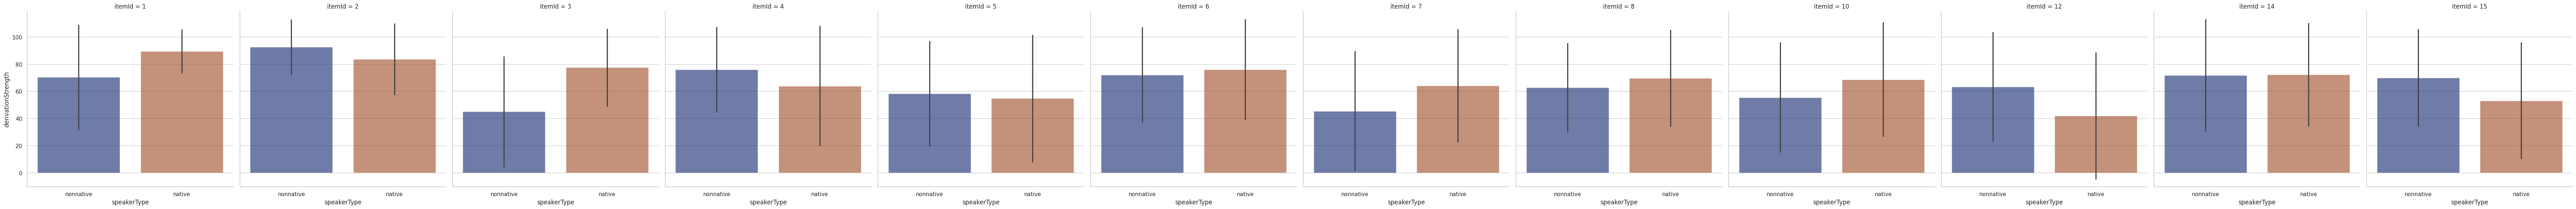

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

truly_difficult_items = [9, 11, 13, 16]
removed_faces = final_df[~final_df["itemId"].isin(truly_difficult_items)]

crit_only = removed_faces[removed_faces["itemType"] == "critical"]
# crit_only = ignore_13[ignore_13["itemType"] == "critical"]

sns.catplot(
    data=crit_only, kind="bar",
    x="speakerType", y="derivationStrength", height=6, col="itemId",
    hue="speakerType", errorbar="sd", palette="dark",
    alpha=.6,
)

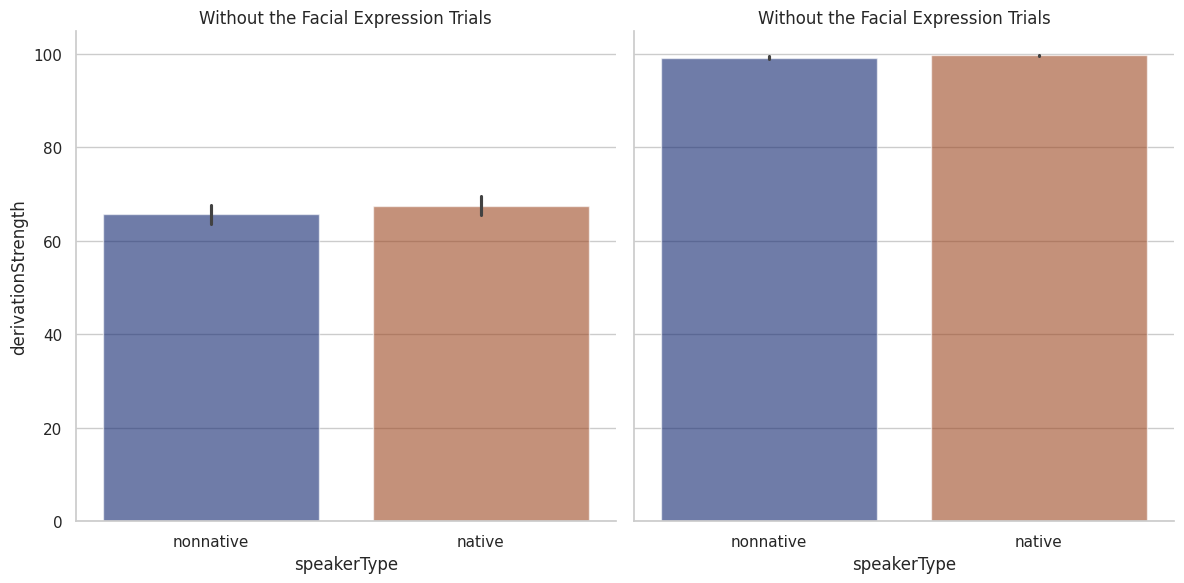

In [22]:
faceless = sns.catplot(
    data=removed_faces, kind="bar",
    x="speakerType", y="derivationStrength", height=6, col="itemType",
    hue="speakerType", errorbar="se", palette="dark",
    alpha=.6,
).set(title='Without the Facial Expression Trials')

# TODO group by ToM

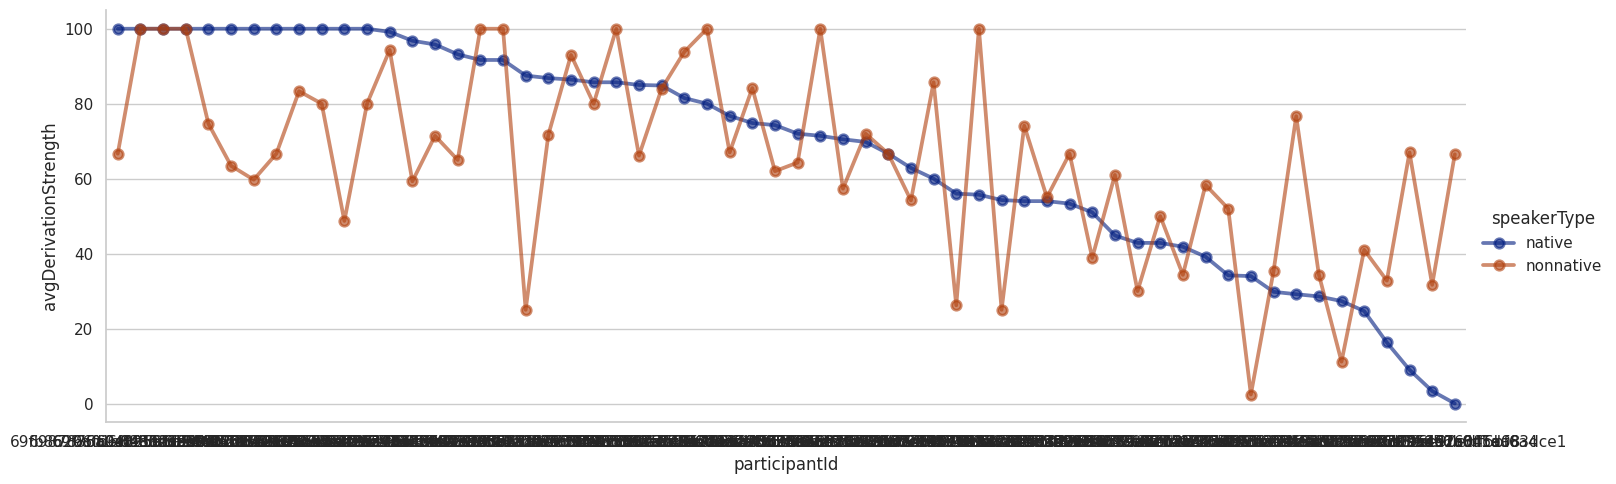

In [23]:
sorted_indiv_derivation_scores = crit_only.groupby(["participantId", "speakerType"])["derivationStrength"].mean().reset_index(
    name='avgDerivationStrength'
)

crits = sorted_indiv_derivation_scores[
    sorted_indiv_derivation_scores["speakerType"] == "native"
].sort_values(["avgDerivationStrength"], ascending=False).rename(columns={"avgDerivationStrength": "sortkey"})

sorted_indiv_derivation_scores = sorted_indiv_derivation_scores.merge(
    crits[["participantId", "sortkey"]], on="participantId"
).sort_values(["sortkey"], ascending=False)

# sorted_indiv_derivation_scores["range"] = range(1, len(sorted_indiv_derivation_scores) + 1)

sns.catplot(
    data=sorted_indiv_derivation_scores, kind="point",
    x="participantId", y="avgDerivationStrength",
    hue="speakerType", errorbar="sd", palette="dark",
    alpha=.6, height=5, aspect=3
)

# TODO:
# plot the difference between the two lines and order it
# axis: diff in rating for nonnative - native x ToM score

# exploratory: look at group of people who do find effect

# EXPLORATORY

In [191]:
final_df[final_df["participantId"] == "66b153e252bf568e5c9f0ba2"]

,participantId,itemId,itemType,weak,strong,antonym,lowfreq1,lowfreq2,derivationStrength,strongRating,antonymRating,speakerType,speakerGender,weakRank,weakFreq,strongRank,strongFreq,antonymRank,antonymFreq,freqRatio


In [ ]:
df[df["workerid"] == "699e4bcadd64768ae7feedad"]